# Quantum Phase Estimation

This tutorial outlines the way quantum phase estimation is implemented in Workbench Algorithms and the way users are expected to interact with it. It is *not* intended to be a tutorial on the conceptual framework behind QPE.

In [1]:
from psiqdk.workbench import QPU, QUFixed, QUInt, Qubits, Qubrick
from psiqdk.workbench.utils.numpy_utils import reverse_numpy_op
from psiqdk.algorithms import (
    CoherentIterativeQPE,
    DoublePhaseKickbackQPE,
    IterativeQPE,
    LCU,
    PrepareNaive,
    QPE,
    Qubitization,
    QubitizedWalkOperator,
    SelectNaive,
)
from psiqdk.algorithms.utils import (
    get_exactly_representable_qubitized_hamiltonian,
    phase_to_energy_qubitization,
    pauli_sum_to_numpy
)
import numpy as np

## Quantum phase estimation: the problem

In QPE we are given a unitary $U$ and seek to extract its eigenphase $e^{2\pi i \phi}$. Our goal is to obtain a `bits_of_precision`-bit estimate of the eigenphase $\phi$, loaded into a quantum register.

> Typically, in Workbench we think of `Qubits` objects as unsigned quantum integers in little-endian encoding (least significant bit stored first). This means that measuring the bitstring `1101` corresponds to the value $1*1 + 1*2 + 0*4 + 1*8 = 11$.
>
> However, this is not the only datatype we are interested in! We can also have unsigned fixed point numbers, which are convenient for storing the eigenphase output from QPE. In this tutorial, we focus on fixed point numbers with radix equal to the length of the bit string, meaning that we interpret the string of measurements `1101` to mean $\frac12 + \frac14 + \frac08 + \frac1{16} = 0.8125$. This conversion is automatically handled using the `QUFixed` data type in Workbench.

## QPE variants

There are four different types of QPE algorithms that we can use in Workbench Algorithms:

1. Vanilla QPE (`QPE` Qubrick): Textbook QPE, with controlled unitary applications followed by inverse quantum Fourier transform.
2. Iterative QPE(`IterativeQPE` Qubrick): QPE where each phase bit is measured sequentially and used to "break up" the inverse QFT.
3. Coherent iterative QPE (`CoherentIterativeQPE` Qubrick): Same concept as iterative QPE, but the rotations required to implement the inverse QFT are performed coherently using controls.
4. Double Phase Kickback QPE (`DoublePhaseKickbackQPE` Qubrick): This version of QPE only works when using Qubitization. It uses a double-phase kickback trick in order to reduce the number of calls to the unitary by a factor of 2.

In the first set of examples, we will use a simple phase gate to demonstrate the setup for each routine:

$$Phase(\phi) = \begin{pmatrix}
            1 & 0 \\
            0 & e^{i\phi}
            \end{pmatrix}$$ 

The eigenphase of the $\ket{1}$ eigenstate of this unitary is exactly $\phi$.

> You can substitute it for any other unitary. The final example will show how straightforward this is by swapping to a qubitized unitary. 

The phase unitary is defined below, along with the constants that specify an exactly representable phase we'll use in the example.

In [2]:
class SimplePhaseUnitary(Qubrick):
    """A Qubrick wrapper for the phase gate for debugging QPE routines.

    Allows for exact eigenphases to be implemented in QPE.
    """

    def __init__(self, phase: float, **kwargs):
        """Initialize the Qubrick.

        Args:
            phase: Phase, as a fraction of 2π.
        """
        self.phase = phase
        super().__init__(**kwargs)

    def _compute(self, psi: Qubits, ctrl: Qubits | int = 0):
        """Apply the Rz gate.

        Args:
            psi: State register for the computation.
            ctrl: Register to control the unitary on. Defaults to ``0``.
        """
        theta = 360 * self.phase
        psi.phase(theta, cond=ctrl)

# Define the phase
bits_of_precision = 4
phase = 1/2 + 1/4 + 1/16  # corresponds to exactly representable bitstring 1101

## Vanilla QPE

The following example demonstrates how to set up phase estimation inputs and run vanilla phase estimation algorithm implemented by the [`QPE`](https://construct.psiquantum.com/docs/psiqdk-algorithms/autoapi/psiqdk/algorithms/index.html#psiqdk.algorithms.QPE) Qubrick.

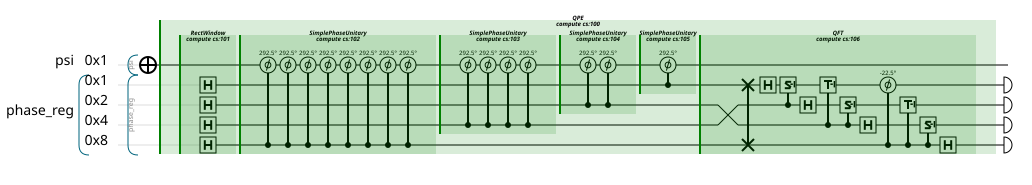

In [3]:
def run_qpe_example(qpe_class):
    qpu = QPU(num_qubits=bits_of_precision + 1)
    psi = QUInt(1, "psi", qpu)    # the eigenstate register
    phase_reg = QUFixed(bits_of_precision, bits_of_precision, "phase_reg", qpu)

    # Initialize the Qubricks
    unitary = SimplePhaseUnitary(phase=phase)
    qpe = qpe_class(bits_of_precision=bits_of_precision, unitary=unitary)

    # Prepare the eigenstate |1⟩ (hardcoded)
    psi.x()

    # Apply the QPE
    qpe.compute(psi, phase_reg)

    # Read out the resulting phase and check that it matches
    result = phase_reg.read()
    assert result == phase

    qpu.draw(show_qubricks=True)

run_qpe_example(QPE)

## Iterative QPE

The following code snippet reuses the setup from the previous example to show how to swap the QPE Qubrick for [`IterativeQPE`](https://construct.psiquantum.com/docs/psiqdk-algorithms/autoapi/psiqdk/algorithms/index.html#psiqdk.algorithms.IterativeQPE).

> Note that for iterative QPE we can use a single auxiliary qubit to load all the phases, though it requires a slight change in the the method of getting the result compared to the other methods. You can see an example of doing that in the [Iterative QPE tutorial](./Iterative_QPE.ipynb).

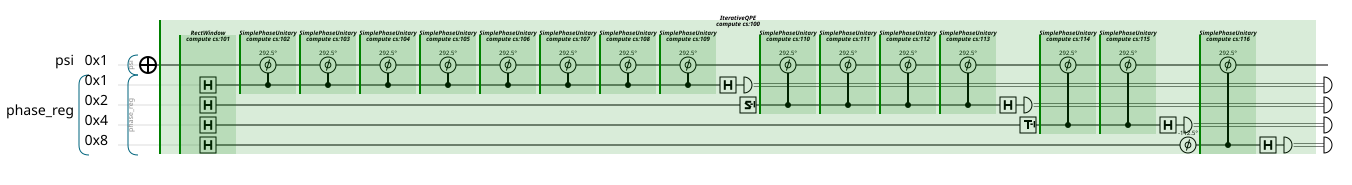

In [4]:
run_qpe_example(IterativeQPE)

## Coherent iterative QPE

The following code snippet reuses the setup from the first example to show how to swap the QPE Qubrick for [`CoherentIterativeQPE`](https://construct.psiquantum.com/docs/psiqdk-algorithms/autoapi/psiqdk/algorithms/index.html#psiqdk.algorithms.CoherentIterativeQPE).

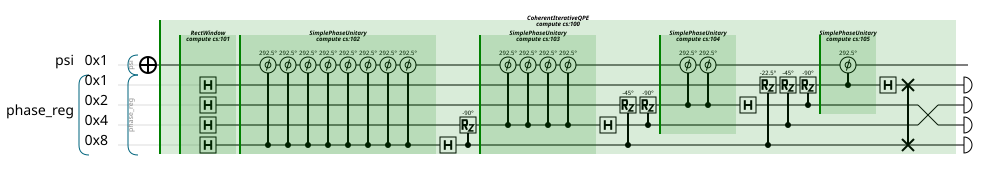

In [5]:
run_qpe_example(CoherentIterativeQPE)

## Extension to qubitization

We can also use QPE to extract the eigenphases of more complex unitaries by swapping out the `unitary` part of the code. Everything else remains *almost* identical (we also need to pass some `**unitary_kwargs` to the `compute` call to ensure that the qubitization is implemented correctly). 

For this example, we will use a block encoding of a two-qubit Hamiltonian designed so that the arccosine of its eigenvalue is exactly representable with `bits_of_precision` bits. The following code snippet shows how to set up this Hamiltonian and what its `PauliSum` and matrix representations look like.

> The process will be identical for any Hamiltonian. To use this code for actual projects, simply replace `ham` with your Hamiltonian of choice and change the state prep portion of the setup code to prepare the desired eigenstate.

In [6]:
bits_of_precision = 3
alpha = 0.3   # arbitrary
ham = get_exactly_representable_qubitized_hamiltonian(
    alpha=alpha,
    bits_of_precision=bits_of_precision,
)[0]

eig_values, _ = np.linalg.eigh(
    reverse_numpy_op(pauli_sum_to_numpy(ham))
)

# We've set up our Hamiltonian so that
# the second eigenvalue is exactly representable
eigenvalue = eig_values[2]

print(ham)
print(pauli_sum_to_numpy(ham).real.round(4))
print(f"Eigenvalue = {float(eigenvalue)}")

0.3*Z0
+ 0.12426406871192847*Z1
+ 0.42426406871192845*I
[[0.8485 0.     0.     0.    ]
 [0.     0.6    0.     0.    ]
 [0.     0.     0.2485 0.    ]
 [0.     0.     0.     0.    ]]
Eigenvalue = 0.6


The following example shows how to obtain block encoding of this Hamiltonian and use it with the QPE. (For more details on the Hamiltonian setup, see [LCU and Qubitization tutorial](./LCU_Qubitization.ipynb)).

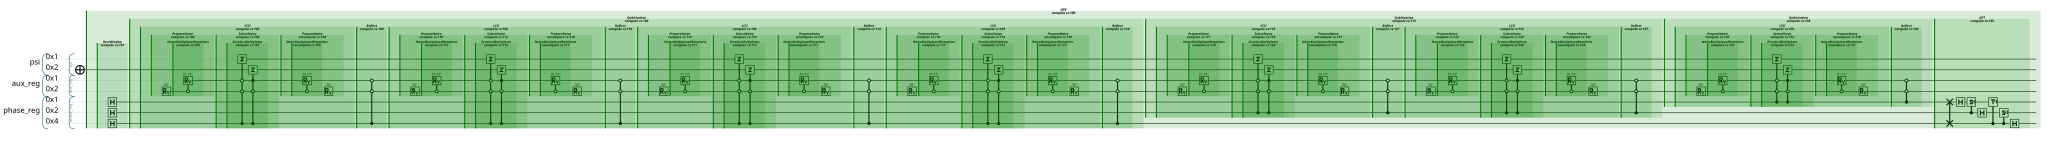

In [7]:
# Set up the qubitized unitary
prepare = PrepareNaive(coeffs=ham.get_coefficients())
select = SelectNaive()
block_encoding = LCU(prepare, select)
unitary = Qubitization(block_encoding)

# Set up QPU and registers
qpu = QPU(num_qubits=7)
psi = QUInt(2, "psi", qpu)            # The eigenstate register
aux_reg = QUInt(2, "aux_reg", qpu)    # Auxiliary qubits for LCU
phase_reg = QUFixed(bits_of_precision, bits_of_precision, "phase_reg", qpu)

# Prepare the eigenstate
psi[1].x()

# Initialize and use the QPE qubrick
qpe = QPE(bits_of_precision=bits_of_precision, unitary=unitary)
qpe.compute(psi, phase_reg, **{"be_ancilla_reg": aux_reg, "data": ham})

qpu.draw(show_qubricks=True)

Since we've used a qubitization iterate, we can't just compare the eigenphase we generated earlier to the output: we need to undo the arccosine introduced by qubitization.

In [8]:
# Compare true value to measured value
result = phase_to_energy_qubitization(phase_reg.read(), ham.norm())
assert np.isclose(eigenvalue, result)

## Double phase kickback QPE

The main advantage of using double phase kickback QPE is that it reduces the number of calls to our unitary by about a factor of 2. This is because it employs a double-phase kickback trick which is outlined in Figure 2 of "Encoding Electronic Spectra in Quantum Circuits with Linear T Complexity" ([arXiv:1805.03662](https://arxiv.org/abs/1805.03662)). To use the [`DoublePhaseKickbackQPE`]((https://construct.psiquantum.com/docs/psiqdk-algorithms/autoapi/psiqdk/algorithms/index.html#psiqdk.algorithms.DoublePhaseKickbackQPE)) Qubrick, we must use the `QubitizedWalkOperator` as our unitary. One key difference from using the standard `Qubitization` Qubrick, shown above, is that you must call your $\text{PREPARE}$ Qubrick on the auxiliary register first, before running `QubitizedWalkOperator`.

The following example shows how to use `DoublePhaseKickbackQPE` with the same Hamiltonian we analyzed in the previous example.

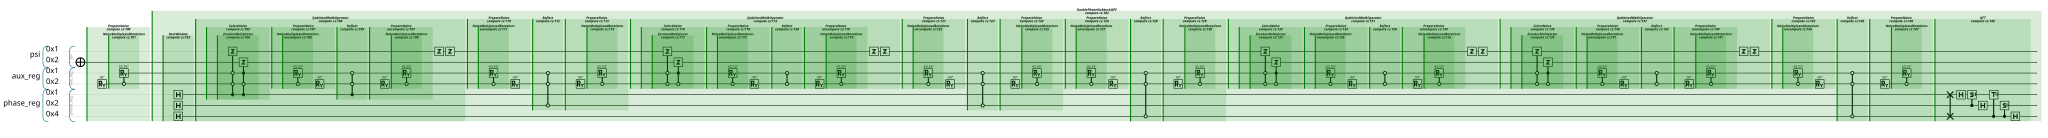

In [9]:
# Set up the qubitized unitary
prepare = PrepareNaive(coeffs=ham.get_coefficients())
select = SelectNaive()
unitary = QubitizedWalkOperator(prepare, select)

# Set up QPU and registers
qpu = QPU(num_qubits=7)
psi = QUInt(2, "psi", qpu)            # The eigenstate register
aux_reg = QUInt(2, "aux_reg", qpu)    # Auxiliary qubits for LCU
phase_reg = QUFixed(bits_of_precision, bits_of_precision, "phase_reg", qpu)

# Prepare the eigenstate
psi[1].x()

# Initialize the DoublePhaseKickbackQPE qubrick 
# NOTE: we need to pass in the prepare Qubrick from our block encoding as well!
qpe = DoublePhaseKickbackQPE(bits_of_precision=bits_of_precision, unitary=unitary)

# Call PREPARE first since we are using QubitizedWalkOperator 
prepare.compute(aux_reg)

# Run the QPE
qpe.compute(psi, phase_reg, **{"be_ancilla_reg": aux_reg, "data": ham})

qpu.draw(show_qubricks=True)

# Compare true value to measured value
result = phase_to_energy_qubitization(phase_reg.read(), ham.norm())
assert np.isclose(eigenvalue, result)

When looking at this circuit, we can see that our unitary (`QubitizedWalkOperator`) is only applied $4$ times instead of the $7$ times that the unitary (`Qubitization`) is applied when using traditional `QPE` using `Qubitization`.

## Summary

In this tutorial, we walked through the different algorithms of phase estimation implemented by Workbench Algorithms.

In the next tutorial, we will dive deeper into [iterative QPE](./Iterative_QPE.ipynb) and compare its behavior with vanilla QPE.